# <center>Category 3: Prescriptive Analysis</center>

### 1. Gender vs Time in Hyperglycemia - Do male and female patients spend different amounts of time in hyperglycemia (glucose > 180)?

##### **Reason:** This question helps identify whether male and female patients spend different amounts of time in a hyperglycemic state (glucose > 180 mg/dL). Research suggests that hormonal differences between males and females can influence insulin sensitivity and glucose regulation. In female T1DM patients, fluctuations in estrogen and progesterone levels may contribute to greater variability in blood glucose levels. Comparing hyperglycemia duration between genders in this dataset can help determine whether similar patterns are observed here.

*** Hyperglycemia % per Patient with Gender ***
   patient_id  total_readings  hyper_readings  hyper_percentage  gender
0   HUPA0001P            4096            1723             42.07    Male
1   HUPA0002P            3181             466             14.65    Male
2   HUPA0003P            3770             954             25.31    Male
3   HUPA0004P            3184            1448             45.48  Female
4   HUPA0005P            3858             973             25.22    Male
5   HUPA0006P            2290             809             35.33    Male
6   HUPA0007P            3857            1743             45.19    Male
7   HUPA0009P            3812            2232             58.55  Female
8   HUPA0010P            2976             501             16.83    Male
9   HUPA0011P            3839            1238             32.25  Female
10  HUPA0014P            3829            1987             51.89    Male
11  HUPA0015P            3792            1409             37.16  Female
12  HUPA0016P   

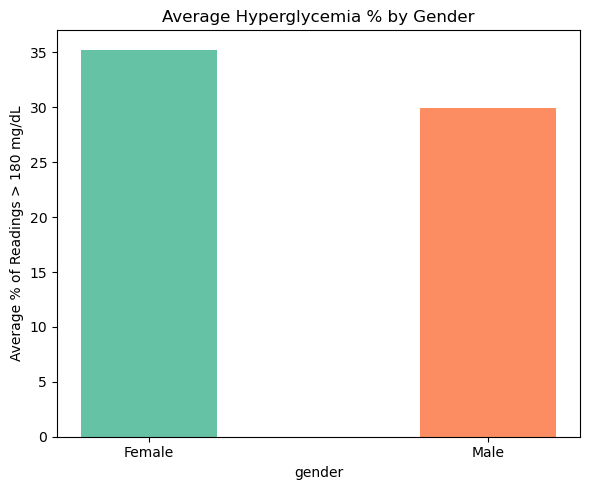

In [3]:
#Importing all the Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter("ignore", UserWarning)

# Reading file
df_all = pd.read_excel("Team6_DataDynamos_Python-Hackathon_MAY2026_V2.xlsx")

# Calculating hyperglycemia readings per patient
total_readings   = df_all.groupby('patient_id')['glucose'].count()
hyper_readings   = df_all[df_all['glucose'] > 180].groupby('patient_id')['glucose'].count()

# Dataframe summary per patient with gender
hyper_summary = pd.DataFrame({
    'total_readings' : total_readings,
    'hyper_readings' : hyper_readings,
    'hyper_percentage': ((hyper_readings / total_readings) * 100).round(2)}).fillna(0).reset_index()

# Adding gender column to the dataframe and merging using left join
patient_gender = df_all[['patient_id', 'gender']].drop_duplicates()
hyper_summary  = hyper_summary.merge(patient_gender, on='patient_id', how='left')

print("*** Hyperglycemia % per Patient with Gender ***")
print(hyper_summary)

# Finding average hyperglycemia % by gender
gender_summary = hyper_summary.groupby('gender')['hyper_percentage'].agg(
    Mean_Hyper_Pct = 'mean',
    Patient_Count  = 'count'
).round(2)

print("\n*** Average % in Hyperglycemia by Gender ***")
print(gender_summary)

# Visualization
# Bar Chart 1 - Average hyperglycemia % by gender
x1 = gender_summary.index
y1 = gender_summary['Mean_Hyper_Pct']

plt.figure(figsize=(6, 5))
plt.bar(x1, y1, width=0.4, color=plt.cm.Set2(range(len(x1))))
plt.title('Average Hyperglycemia % by Gender')
plt.xlabel('gender')
plt.ylabel('Average % of Readings > 180 mg/dL')
plt.tight_layout()
plt.show()

**<span style="color:green">Key Insights: The average hyperglycemia in female patients is 35.25% when compared to male patients which is, 29.96%. In T1DM, hormonal fluctuations in female patients (estrogen and progesterone) are known to affect insulin sensitivity, which can cause unpredictable glucose swings. As seen in the above insights a higher hyperglycemia % in females may reflect these hormonal effects on glucose regulation.  </green>**

### 2. Basal Rate vs Overnight Glucose Stability - Do patients with higher overnight basal rates have more stable glucose between 12AM–6AM?

##### **Reason:** This question is important because the primary purpose of basal insulin is to maintain stable glucose levels during fasting periods and sleep. If glucose levels fluctuate significantly overnight despite a programmed basal rate, it may indicate that the insulin delivery settings are not properly calibrated for the patient’s physiological needs. Ideally, comparing basal rate levels to overnight glucose variance should directly test whether the pump settings are working as intended.

In [4]:
# Reading file
df = pd.read_excel("Team6_DataDynamos_Python-Hackathon_MAY2026_V2.xlsx")

# Filtering overnight readings (12AM - 6AM)
df['time'] = pd.to_datetime(df['time'], format='%H:%M:%S').dt.time
overnight  = df[df['time'].apply(lambda x: x >= pd.Timestamp('00:00').time() and x <= pd.Timestamp('06:00').time())]

print(f"Total overnight readings : {len(overnight)}")

# Calculating glucose stability (standard deviation) per patient overnight
overnight_stability = overnight.groupby('patient_id').agg(
    avg_glucose     = ('glucose',    'mean'),
    std_glucose     = ('glucose',    'std'),
    avg_basal_rate  = ('basal_rate', 'mean')
).round(2).reset_index()

# Sorting by average standard deviation glucose descending
overnight_stability = overnight_stability.sort_values(
    by='std_glucose',
    ascending=False
)

print("\n*** Overnight Glucose Stability per Patient ***")
print(overnight_stability)

Total overnight readings : 78173

*** Overnight Glucose Stability per Patient ***
   patient_id  avg_glucose  std_glucose  avg_basal_rate
5   HUPA0006P       153.10        96.78            0.08
12  HUPA0016P       165.11        89.90            0.09
16  HUPA0020P       217.86        84.06            0.08
2   HUPA0003P       150.45        81.78            0.06
10  HUPA0014P       212.99        79.90            0.00
6   HUPA0007P       144.08        78.54            0.09
20  HUPA0024P       157.35        76.07            0.04
0   HUPA0001P       173.11        76.05            0.05
3   HUPA0004P       141.91        69.19            0.08
15  HUPA0019P       171.45        68.02            0.06
14  HUPA0018P       175.90        67.73            0.00
22  HUPA0026P       159.14        67.18            0.04
13  HUPA0017P       223.92        59.21            0.06
1   HUPA0002P       104.22        56.67            0.08
11  HUPA0015P       156.60        53.56            0.00
8   HUPA0010P       11

**<span style="color:green">Key Insights: The overnight glucose analysis revealed substantial variability in glucose stability across patients. Patients such as HUPA0006P, HUPA0016P, and HUPA0020P exhibited high glucose standard deviations, indicating unstable overnight glycemic control. However, higher glucose variability did not consistently correspond to lower or higher basal insulin rates. For example, patients HUPA0022P and HUPA0025P maintained comparatively lower glucose variability despite receiving relatively higher basal rates. These findings suggest that overnight glucose stability may be influenced by multiple factors beyond basal insulin dosing alone, including insulin sensitivity, meal timing, lifestyle behaviors, and correction bolus administration.</green>**